# AuraFitness AI Export Validation

This notebook validates the final app-friendly AI export files.

Exports:

- exercises.json
- ai_rules.json
- recommendations.json
- model_metadata.json
- typescript_interfaces.ts

Rules:

- No React app yet
- No Codex app prompt yet
- Validate exports before app integration

In [1]:
from pathlib import Path
import sys
import json

import pandas as pd
import matplotlib.pyplot as plt

AI_ROOT = Path.cwd()

if AI_ROOT.name == "notebooks":
    AI_ROOT = AI_ROOT.parent

if str(AI_ROOT) not in sys.path:
    sys.path.append(str(AI_ROOT))

from scripts.export_ai_data import main as export_ai_data
from scripts.validate_exports import run_validation

EXPORTS_DIR = AI_ROOT / "exports"
FIGURES_DIR = AI_ROOT / "reports" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("AI root:", AI_ROOT)
print("Exports dir:", EXPORTS_DIR)

AI root: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai
Exports dir: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\exports


## Run export script

This cell generates the app-friendly AI export files.

In [2]:
export_ai_data()

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\exports\exercises.json
Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\exports\ai_rules.json
Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\exports\recommendations.json
Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\exports\model_metadata.json
Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\exports\typescript_interfaces.ts

AuraFitness AI exports completed.
Exercise count exported: 1730


## Validate export files

This cell checks whether required export files exist and whether important structures are valid.

In [3]:
run_validation()

PASS: export_file_exists_exercises.json -> C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\exports\exercises.json
PASS: export_file_exists_ai_rules.json -> C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\exports\ai_rules.json
PASS: export_file_exists_recommendations.json -> C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\exports\recommendations.json
PASS: export_file_exists_model_metadata.json -> C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\exports\model_metadata.json
PASS: export_file_exists_typescript_interfaces.ts -> C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\exports\typescript_interfaces.ts
PASS: exercises_is_list -> type=list
PASS: exercise_count_minimum -> count=1730
PASS: exercise_required_keys -> missing=[]
PASS: exercise_ids_unique -> duplicate_ids=0
PASS: recommendations_required_keys -> missing=[]
PASS: recommendations_samples_only -> samplesOnly=True
PASS: exercise_recommendations_available -> count=5
PASS: metadata_uses_ml_false -

## Load export summary

This cell loads the exported files and creates a summary table.

In [4]:
export_files = [
    "exercises.json",
    "ai_rules.json",
    "recommendations.json",
    "model_metadata.json",
    "typescript_interfaces.ts",
]

summary_rows = []

for filename in export_files:
    file_path = EXPORTS_DIR / filename

    summary_rows.append({
        "filename": filename,
        "exists": file_path.exists(),
        "size_kb": round(file_path.stat().st_size / 1024, 2) if file_path.exists() else 0,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,filename,exists,size_kb
0,exercises.json,True,1218.67
1,ai_rules.json,True,3.52
2,recommendations.json,True,9.12
3,model_metadata.json,True,1.56
4,typescript_interfaces.ts,True,3.29


## Chart export file sizes

This chart checks the relative size of exported app integration files.

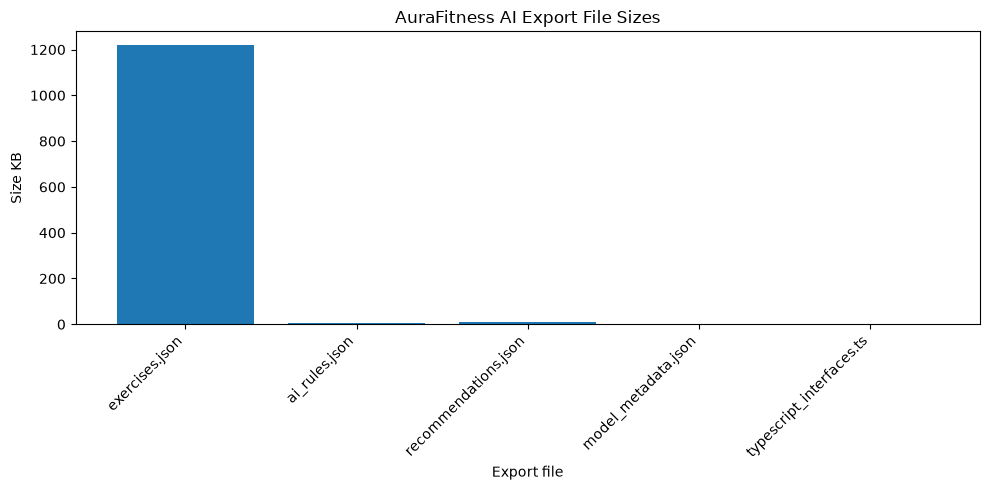

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\ai_export_file_sizes.png


In [5]:
plt.figure(figsize=(10, 5))
plt.bar(summary_df["filename"], summary_df["size_kb"])
plt.title("AuraFitness AI Export File Sizes")
plt.xlabel("Export file")
plt.ylabel("Size KB")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

output_path = FIGURES_DIR / "ai_export_file_sizes.png"
plt.savefig(output_path, dpi=150)
plt.show()

print("Saved:", output_path)

## Preview exercises export

This previews the first few exported exercises.

In [6]:
with open(EXPORTS_DIR / "exercises.json", "r", encoding="utf-8") as file:
    exercises = json.load(file)

print("Exercise count:", len(exercises))
display(pd.DataFrame(exercises).head())

Exercise count: 1730


,id,name,bodyPart,targetMuscle,secondaryMuscles,equipment,exerciseType,difficultyLevel,instructions,sourceDataset
0,ex_0e2eff7dc4,3/4 sit-up,abdominals,abdominals,[],bodyweight,strength,unknown,unknown,gym_exercises
1,ex_a66a59d23a,Ab Roller,abdominals,abdominals,[],other,strength,unknown,unknown,gym_exercises
2,ex_b1ced5f64e,Ab bicycle,abdominals,abdominals,[],bodyweight,strength,unknown,unknown,gym_exercises
3,ex_32a5b22d7e,Barbell Ab Rollout - On Knees,abdominals,abdominals,[],barbell,strength,unknown,unknown,gym_exercises
4,ex_3f76f9aa3b,Barbell roll-out,abdominals,abdominals,[],barbell,strength,unknown,unknown,gym_exercises


## Preview recommendation export

This previews sample recommendation outputs for React app integration testing.

In [7]:
with open(EXPORTS_DIR / "recommendations.json", "r", encoding="utf-8") as file:
    recommendations = json.load(file)

print("Recommendation export keys:")
print(recommendations.keys())

print("\nSample motivation message:")
print(recommendations["motivationMessage"])

print("\nSample calorie estimate:")
print(recommendations["calorieEstimate"])

Recommendation export keys:
dict_keys(['version', 'createdAt', 'samplesOnly', 'note', 'exerciseRecommendations', 'overload', 'restDay', 'calorieEstimate', 'streakInsights', 'motivationMessage'])

Sample motivation message:
{'event_type': 'workout_completed', 'title': 'Workout completed', 'message': 'Upamada, you completed Push Day. You are 3/5 workouts into this week. Keep stacking wins.', 'tone': 'positive', 'confidence': 0.86, 'reason_codes': ['workout_completed', 'weekly_progress_available']}

Sample calorie estimate:
{'estimated_calories': 332.5, 'met_value': 3.5, 'activity_key': 'strength_general', 'activity_label': 'Resistance training, multiple exercises, 8-15 reps at varied resistance', 'duration_hours': 1.0, 'confidence': 0.9, 'formula': 'calories = MET * body_weight_kg * duration_hours', 'reason_codes': ['activity_key_matched_directly'], 'warning': None}
